In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("retail_sales.csv")

print(df.head())

         Date  Sales
0  2020-01-01    927
1  2020-02-01    957
2  2020-03-01   1027
3  2020-04-01   1104
4  2020-05-01   1085


In [16]:
#Currently, Pandas usually reads Date as a string/object. For Time Series, we need it as a proper date/time type.

df['Date']=pd.to_datetime(df['Date'])
print(df.dtypes)

Date     datetime64[us]
Sales             int64
dtype: object


In [17]:
#In Time Series, we usually keep the date as the index because our data is organized according to time.

df.set_index('Date',inplace=True)  # now your Date is the index, and Sales is the column containing the values.
df.head()

,Sales
Date,
2020-01-01,927
2020-02-01,957
2020-03-01,1027
2020-04-01,1104
2020-05-01,1085


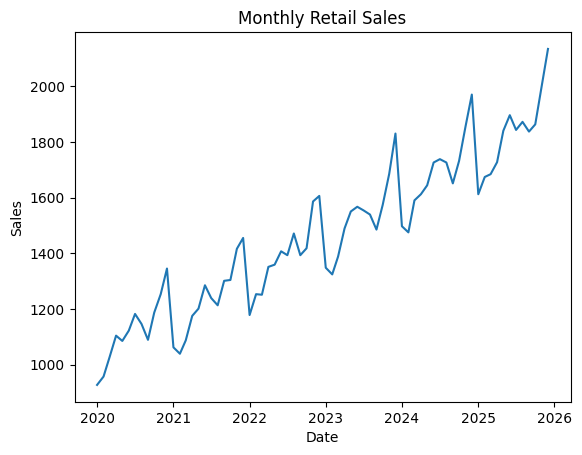

"As time (years) increases → Sales generally increase.This is called an upward trend.\nBut look carefully at the graph: sales don't increase smoothly. There are ups and downs within each year.\nThat repeating pattern is what we call seasonality."

In [20]:
# We want to see how Sales change over time.

plt.plot(df.index,df['Sales'])
plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Monthly Retail Sales')

plt.show()

'''As time (years) increases → Sales generally increase.This is called an upward trend.
But look carefully at the graph: sales don't increase smoothly. There are ups and downs within each year.
That repeating pattern is what we call seasonality.'''

In [22]:
df['Month']=df.index.month
print(df.groupby('Month')['Sales'].mean())

'''This calculates the average sales for each month across all 6 years.
For example:
Month
January   → lower
February  → lower
...
November  → higher
December  → highest  ---> like this...'''

Month
1     1270.666667
2     1287.000000
3     1337.833333
4     1409.666667
5     1446.500000
6     1500.500000
7     1491.500000
8     1494.500000
9     1459.333333
10    1513.000000
11    1632.833333
12    1723.333333
Name: Sales, dtype: float64


In [ ]:
'''we cannot analyze daily sales from this dataset because we only have one sales value per month in our dataset(csv)

Our dates are:
2020-01-01
2020-02-01
2020-03-01
...

In [24]:
#The main purpose of Rolling Mean is to see the overall trend of the data by reducing short-term fluctuations/noise.Understand seasonality/trend
#without rolling mean Sales go up and down every month.

df['Rolling Mean']=df['Sales'].rolling(window=12).mean()   # why windows=12 , Our data is monthly.
print(df.head(15))

# Pandas needs 12 values to calculate the first rolling mean and starting all don't have past 12 values so they are nan...

            Sales  Month  Rolling Mean
Date                                  
2020-01-01    927      1           NaN
2020-02-01    957      2           NaN
2020-03-01   1027      3           NaN
2020-04-01   1104      4           NaN
2020-05-01   1085      5           NaN
2020-06-01   1122      6           NaN
2020-07-01   1182      7           NaN
2020-08-01   1146      8           NaN
2020-09-01   1089      9           NaN
2020-10-01   1187     10           NaN
2020-11-01   1253     11           NaN
2020-12-01   1345     12   1118.666667
2021-01-01   1062      1   1129.916667
2021-02-01   1039      2   1136.750000
2021-03-01   1087      3   1141.750000


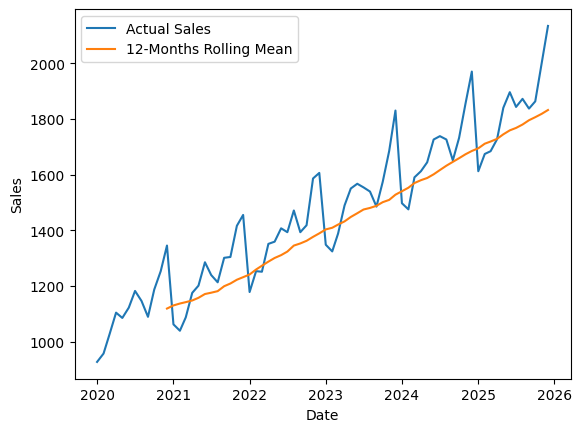

In [26]:
plt.plot(df['Sales'],label='Actual Sales')
plt.plot(df['Rolling Mean'],label='12-Months Rolling Mean')

plt.xlabel('Date')
plt.ylabel('Sales')
plt.title("Sales and 12-Month Rolling Mean")
plt.legend()

plt.show()

In [29]:
from sklearn.model_selection import train_test_split

train,test=train_test_split(
    df,
    test_size=0.20,
    shuffle=False            # random_state ❌ not needed here,,,shuffle=False ✅ important for Time Series
)
print(train.tail())
print(test.head())

            Sales  Month  Rolling Mean
Date                                  
2024-05-01   1644      5   1587.666667
2024-06-01   1726      6   1600.916667
2024-07-01   1738      7   1616.250000
2024-08-01   1726      8   1631.833333
2024-09-01   1651      9   1645.666667
            Sales  Month  Rolling Mean
Date                                  
2024-10-01   1732     10   1658.833333
2024-11-01   1856     11   1673.083333
2024-12-01   1970     12   1684.750000
2025-01-01   1612      1   1694.333333
2025-02-01   1674      2   1710.916667


In [32]:
# Before using ARIMA/SARIMA, we need to check whether our time series is stationary. Is my time-series data stationary?

from statsmodels.tsa.stattools import adfuller      # adfuller() means Augmented Dickey-Fuller test (ADF test).

result = adfuller(train["Sales"])       # adfuller(train['Sales'])--> "Is my Sales time series stationary?"
print(result)

print("ADF Statistic:", result[0])   # here [0] --> is adf test.
print("p-value:", result[1])         # here [1] --> is p-value.

#p-value < 0.05  → Stationary ✅
#p-value > 0.05  → Not Stationary ❌

'''
| Index       | Value                      | Meaning                                                    |
| ----------- | -------------------------- | ---------------------------------------------------------- |
| `result[0]` | ADF Statistic              | Test statistic                                             |
| `result[1]` | p-value                    | Used to decide stationary/non-stationary                   |
| `result[2]` | Used lag                   | Number of lags used in the test                            |
| `result[3]` | Number of observations     | Observations used after accounting for lags                |
| `result[4]` | Critical values            | Critical values at 1%, 5%, 10%                             |
| `result[5]` | Best information criterion | Maximum information criterion value used to choose the lag |
'''

(1.5929797588063417, 0.997836360847376, 11, 45, {'1%': np.float64(-3.584828853223594), '5%': np.float64(-2.9282991495198907), '10%': np.float64(-2.6023438271604937)}, np.float64(491.52495908219333))
ADF Statistic: 1.5929797588063417
p-value: 0.997836360847376


C:\Users\Rdvel\AppData\Local\Temp\ipykernel_20656\1809297708.py:5: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(train["Sales"])       # adfuller(train['Sales'])--> "Is my Sales time series stationary?"


'\n| Index       | Value                      | Meaning                                                    |\n| ----------- | -------------------------- | ---------------------------------------------------------- |\n| `result[0]` | ADF Statistic              | Test statistic                                             |\n| `result[1]` | p-value                    | Used to decide stationary/non-stationary                   |\n| `result[2]` | Used lag                   | Number of lags used in the test                            |\n| `result[3]` | Number of observations     | Observations used after accounting for lags                |\n| `result[4]` | Critical values            | Critical values at 1%, 5%, 10%                             |\n| `result[5]` | Best information criterion | Maximum information criterion value used to choose the lag |\n'

In [33]:
#Since our sales data has an upward trend, we need to remove that trend and make the series more stationary.

train["Sales_Diff"] = train["Sales"].diff()

print(train[["Sales", "Sales_Diff"]].head(15))

            Sales  Sales_Diff
Date                         
2020-01-01    927         NaN
2020-02-01    957        30.0
2020-03-01   1027        70.0
2020-04-01   1104        77.0
2020-05-01   1085       -19.0
2020-06-01   1122        37.0
2020-07-01   1182        60.0
2020-08-01   1146       -36.0
2020-09-01   1089       -57.0
2020-10-01   1187        98.0
2020-11-01   1253        66.0
2020-12-01   1345        92.0
2021-01-01   1062      -283.0
2021-02-01   1039       -23.0
2021-03-01   1087        48.0


In [34]:
# Then check stationarity again:-

result = adfuller(train["Sales_Diff"].dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

#p-value < 0.05  → Stationary ✅ .. Your result confirms that the differenced series is stationary.

ADF Statistic: -10.635955117820133
p-value: 5.071894566567968e-19


C:\Users\Rdvel\AppData\Local\Temp\ipykernel_20656\3364382505.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(train["Sales_Diff"].dropna())


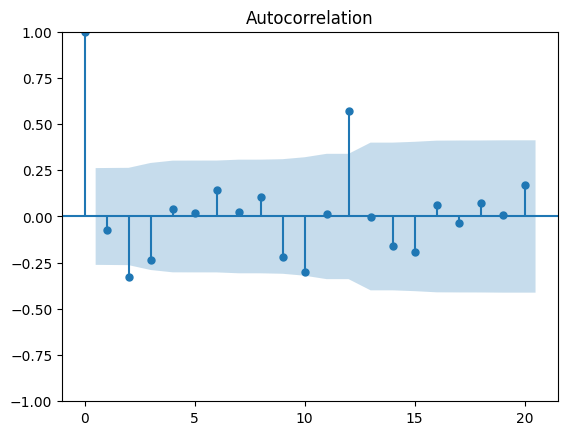

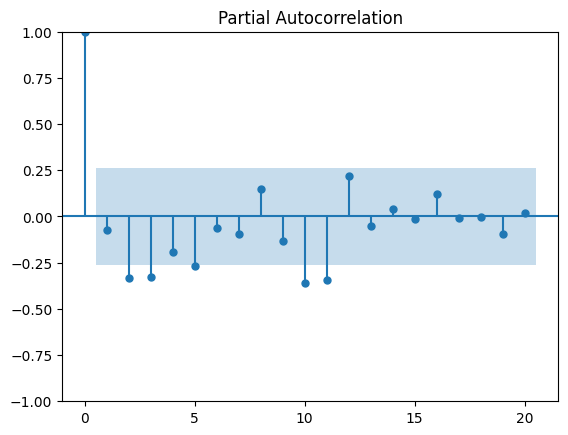

In [35]:
'''WHAT IS ARIMA (P,D,Q):-
P = AR(AUTREGRESSIVE)
P TELLS HOW MANY PREVIOUS VALUES SHOULD I LOOK AT ?

D = DIFFERNCING
D TELLS HOW MANY TIMES SHOULD I DIFFERNECE THE DATA
D=1 THEN 110 - 100 = 10,125 - 110 = 15,140 - 125 = 15
D=2 THEN 10-15 = 5, 15-15=0 LIKE THIS...

Q = (MOVING AVERAGE)
Q TELLS THE MODEL HOW MANY PREVIOUS PREDICTION ERROR SHOULD I USE?
Q=2 the model considers the previous 2 errors when making the next prediction.Mar error = +5,Feb error = +10 JUST 2MONTHS ERROR TAKEN.'''

# Now we use ACF and PACF to understand the lag relationships and help choose ARIMA parameters.

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plot_acf(train["Sales_Diff"].dropna(), lags=20)
plt.show()

plot_pacf(train["Sales_Diff"].dropna(), lags=20)
plt.show()

'''We want to predict the next month's sales.

The model needs to know:
"Do previous months help me predict the current month?"
That's what ACF and PACF are helping us investigate.
ACF  → helps us choose q
PACF → helps us choose p

ACF simply asks:
"Is the current value related to the value from this many months ago?"
That's why your graph has:
0  1  2  3  4  5  ... 20
   ↑  ↑  ↑
  lags
The blue shaded region is basically our normal/random range.If a bar goes outside that blue area, we pay attention to it.
For example:
Lag 1 → small bar
Lag 2 → big negative bar
Lag 3 → small bar
means:
Lag 1 → weak relationship
Lag 2 → stronger relationship
Lag 3 → weak relationship

LAG 12 HAS BIG SIGN SEE ACF LAG 12 --> TELLS US This month's value is related to the value from the same time last year.
if the value 12 months ago is the same as today's value, then that is a very strong example of seasonality.
A big Lag-12 ACF bar does NOT mean the values are exactly equal.There is a strong statistical relationship between the current value and the value 12 months earlier.'''

In [36]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train["Sales"], order=(1, 1, 1))

model_fit = model.fit()

print(model_fit.summary())

'''p = 1 → use 1 previous lag for the AR part
d = 1 → difference the data once
q = 1 → use 1 previous error for the MA part'''

                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   57
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -335.022
Date:                Tue, 06 Oct 2026   AIC                            676.045
Time:                        21:56:11   BIC                            682.121
Sample:                    01-01-2020   HQIC                           678.400
                         - 09-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4546      0.395      1.152      0.250      -0.319       1.228
ma.L1         -0.7565      0.271     -2.787      0.005      -1.289      -0.224
sigma2      9150.1869   2037.957      4.490      0.0

C:\Users\Rdvel\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Rdvel\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Rdvel\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Rdvel\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params


In [37]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    train["Sales"],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12)       # (1,1,1,12) --> (P,D,Q,M) 12 MEANS "Our seasonal pattern repeats every 12 months."
)

model_fit = model.fit()

print(model_fit.summary())

C:\Users\Rdvel\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Rdvel\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Rdvel\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:679: EstimationWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  start_params = self.start_params


                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   57
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -225.662
Date:                            Tue, 06 Oct 2026   AIC                            461.324
Time:                                    21:58:48   BIC                            470.245
Sample:                                01-01-2020   HQIC                           464.632
                                     - 09-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0319      0.270     -0.118      0.906      -0.562       0.498
ma.L1         -0.8617      0.183   

In [39]:
forecast = model_fit.forecast(steps=len(test))

print(forecast)

comparison = pd.DataFrame({
    "Actual": test["Sales"],
    "Predicted": forecast
})

print(comparison)

2024-10-01    1732.878185
2024-11-01    1847.926297
2024-12-01    1910.856735
2025-01-01    1629.261704
2025-02-01    1639.898283
2025-03-01    1690.913174
2025-04-01    1776.178092
2025-05-01    1797.325547
2025-06-01    1847.387548
2025-07-01    1844.088104
2025-08-01    1844.033837
2025-09-01    1814.860946
2025-10-01    1870.212121
2025-11-01    1985.671558
2025-12-01    2057.935704
Freq: MS, Name: predicted_mean, dtype: float64
            Actual    Predicted
2024-10-01    1732  1732.878185
2024-11-01    1856  1847.926297
2024-12-01    1970  1910.856735
2025-01-01    1612  1629.261704
2025-02-01    1674  1639.898283
2025-03-01    1684  1690.913174
2025-04-01    1727  1776.178092
2025-05-01    1840  1797.325547
2025-06-01    1896  1847.387548
2025-07-01    1843  1844.088104
2025-08-01    1872  1844.033837
2025-09-01    1837  1814.860946
2025-10-01    1863  1870.212121
2025-11-01    2001  1985.671558
2025-12-01    2134  2057.935704


In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test["Sales"], forecast)
rmse = np.sqrt(mean_squared_error(test["Sales"], forecast))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 27.775661543988782
RMSE: 35.61040313870091


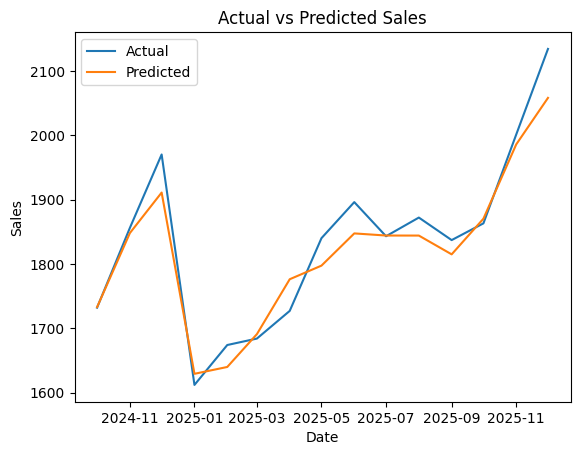

In [41]:
plt.plot(test.index, test["Sales"], label="Actual")
plt.plot(test.index, forecast, label="Predicted")

plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Actual vs Predicted Sales")
plt.legend()
plt.show()

In [42]:
final_model = SARIMAX(
    df["Sales"],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12)
)

final_fit = final_model.fit()

C:\Users\Rdvel\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Rdvel\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [43]:
next_month = final_fit.forecast(steps=1)

print("Predicted Sales for January 2026:", next_month.iloc[0])

Predicted Sales for January 2026: 1784.5481179805938
